# Deadlock Counter Item Effectiveness — Statistical Analysis

**Research questions (from proposal):**
1. Are counter items bought at higher rates when the target hero is on the enemy team?
2. Does buying the counter item improve win rate against that hero, controlling for skill tier?
3. Do results confirm, refute, or complicate community consensus?
4. Does effectiveness differ across skill tiers?

**Counter pairs under study:**

| Item | Target Hero | Counter Mechanism |
|---|---|---|
| Knockdown | Dynamo | Interrupts channeled ultimate |
| Disarming Hex | Haze | Disarm nullifies gun damage |
| Slowing Hex | Mina | Removes escape mobility |
| Dispel Magic | Infernus | Removes damage-over-time stacks |

**Structure:**
- **Part I** — Chi-square tests of independence (item × win/loss; purchase rate × enemy presence)
- **Part II** — Two-proportion Z-tests + logistic regression per pair and broader hero subset
- **Part III** — Volcano plot: all item × hero combinations with FDR correction
- **Secondary** — Rolling time series correlation (purchase rate vs hero win rate)
- **Summary** — Confirmed / Overrated / Undiscovered classification


In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pearsonr, spearmanr
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 40)


In [2]:
COUNTER_PAIRS = {
    'Knockdown':     ('Dynamo',   np.uint32(1254091416)),
    'Disarming Hex': ('Haze',     np.uint32(2061878743)),
    'Slowing Hex':   ('Mina',     np.uint32(1813726886)),
    'Dispel Magic':  ('Infernus', np.uint32(3731635960)),
}

DATA_FILE  = 'data/collected_matches_sample.jsonl'
OTHER_TEAM = {'Team0': 'Team1', 'Team1': 'Team0'}
TIERS      = ['low', 'mid', 'high', 'top']

np.random.seed(42)


In [3]:
items_lookup  = pd.read_parquet('data/public_items.parquet')
heroes_lookup = pd.read_parquet('data/public_heroes.parquet')

# Decode byte-string columns produced by older pyarrow versions
for col in items_lookup.columns:
    items_lookup[col] = items_lookup[col].apply(
        lambda x: x.decode() if isinstance(x, bytes) else x
    )

upgrade_items    = items_lookup[items_lookup['type'] == 'upgrade'].copy()
item_id_to_name  = items_lookup.set_index('id')['name'].to_dict()
hero_id_to_name  = heroes_lookup.set_index('id')['name'].to_dict()
upgrade_item_ids = set(upgrade_items['id'])

print(f'Heroes: {len(heroes_lookup)}  |  Purchasable upgrade items: {len(upgrade_items)}')
display(upgrade_items[['id', 'name', 'tier', 'slot_type', 'cost']].head(5))


Heroes: 38  |  Purchasable upgrade items: 171


,id,name,tier,slot_type,cost
1,7409189,Improved Spirit,2.0,spirit,1600.0
6,26002154,Melee Charge,2.0,weapon,1600.0
8,64550694,Runed Gauntlets,5.0,weapon,9999.0
9,84321454,Quicksilver Reload,2.0,spirit,1600.0
10,98582110,Stalker,2.0,weapon,1600.0


In [4]:
with open(DATA_FILE) as f:
    raw_matches = [json.loads(line) for line in f]

print(f'Loaded {len(raw_matches):,} matches')
print('Top-level keys:', list(raw_matches[0].keys()))


Loaded 1,000 matches
Top-level keys: ['average_badge_team0', 'average_badge_team1', 'banned_hero_ids', 'duration_s', 'game_mode', 'match_id', 'match_mode', 'match_outcome', 'not_scored', 'players', 'start_time', 'winning_team']


In [5]:
player_rows = []
for match in raw_matches:
    match_id     = match['match_id']
    winning_team = match['winning_team']
    duration_s   = match['duration_s']
    start_time   = match['start_time']

    for p in match['players']:
        player_rows.append({
            'match_id':     match_id,
            'start_time':   start_time,
            'duration_s':   duration_s,
            'winning_team': winning_team,
            'team':         p['team'],
            'hero_id':      p['hero_id'],
            'kills':        p['kills'],
            'deaths':       p['deaths'],
            'net_worth':    p['net_worth'],
            'player_level': p['player_level'],
        })

players_df = pd.DataFrame(player_rows)
players_df['won']       = (players_df['team'] == players_df['winning_team']).astype(int)
players_df['hero_name'] = players_df['hero_id'].map(hero_id_to_name)
players_df['start_time'] = pd.to_datetime(players_df['start_time'])

print('players_df shape:', players_df.shape)
display(players_df.head(4))


players_df shape: (12000, 12)


,match_id,start_time,duration_s,winning_team,team,hero_id,kills,deaths,net_worth,player_level,won,hero_name
0,72213176,2026-04-01 10:00:00,2722,Team0,Team1,80,3,9,45720,34,0,Silver
1,72213176,2026-04-01 10:00:00,2722,Team0,Team1,60,19,4,60421,36,0,Sinclair
2,72213176,2026-04-01 10:00:00,2722,Team0,Team0,63,20,9,56691,36,1,Mina
3,72213176,2026-04-01 10:00:00,2722,Team0,Team0,81,1,9,46463,34,1,Celeste


In [6]:
item_rows = []
for match in raw_matches:
    match_id     = match['match_id']
    winning_team = match['winning_team']

    for p in match['players']:
        team    = p['team']
        hero_id = p['hero_id']
        won     = (team == winning_team)

        for item in p['items']:
            item_id = np.uint32(item['item_id'])
            item_rows.append({
                'match_id':    match_id,
                'team':        team,
                'hero_id':     hero_id,
                'won':         won,
                'item_id':     item_id,
                'game_time_s': item['game_time_s'],
                'sold_time_s': item['sold_time_s'],
            })

items_df = pd.DataFrame(item_rows)
items_df['held']       = items_df['sold_time_s'] == 0
items_df['was_sold']   = items_df['sold_time_s'] > 0
items_df['item_name']  = items_df['item_id'].map(item_id_to_name)
items_df['hero_name']  = items_df['hero_id'].map(hero_id_to_name)
items_df['is_upgrade'] = items_df['item_id'].isin(upgrade_item_ids)

print('items_df shape:', items_df.shape)
display(items_df[items_df['is_upgrade']].head(4))


items_df shape: (373384, 12)


,match_id,team,hero_id,won,item_id,game_time_s,sold_time_s,held,was_sold,item_name,hero_name,is_upgrade
1,72213176,Team1,80,False,3862866912,68,2036,False,True,Restorative Shot,Silver,True
4,72213176,Team1,80,False,1437614329,176,2513,False,True,Melee Lifesteal,Silver,True
6,72213176,Team1,80,False,3633614685,225,943,False,True,Extra Health,Silver,True
8,72213176,Team1,80,False,1342610602,335,1506,False,True,Close Quarters,Silver,True


In [7]:
# --- counter item purchase flags per (match, team) ---
target_ids = {iid for _, iid in COUNTER_PAIRS.values()}
target_df  = items_df[items_df['item_id'].isin(target_ids)]

def _flags_to_wide(flags_df, prefix):
    id_to_item = {iid: name for name, (_, iid) in COUNTER_PAIRS.items()}
    flags_df = flags_df.copy()
    flags_df['col'] = prefix + flags_df['item_id'].map(id_to_item)
    return flags_df.pivot_table(
        index=['match_id', 'team'], columns='col', values='flag',
        aggfunc='max', fill_value=0,
    ).reset_index()

held_flags = (
    target_df[target_df['held']]
    .groupby(['match_id', 'team', 'item_id'])
    .size().gt(0).astype(int)
    .rename('flag').reset_index()
)
bought_flags = (
    target_df
    .groupby(['match_id', 'team', 'item_id'])
    .size().gt(0).astype(int)
    .rename('flag').reset_index()
)
held_wide   = _flags_to_wide(held_flags,   'held_')
bought_wide = _flags_to_wide(bought_flags, 'bought_')

# --- enemy hero flags (only the 4 target heroes) ---
target_heroes = {hero for hero, _ in COUNTER_PAIRS.values()}
hero_flags = (
    players_df[players_df['hero_name'].isin(target_heroes)]
    [['match_id', 'team', 'hero_name']]
    .assign(present=1)
    .pivot_table(index=['match_id', 'team'], columns='hero_name',
                 values='present', aggfunc='max', fill_value=0)
    .reset_index()
)
hero_flags.columns = (
    ['match_id', 'team'] + ['enemy_has_' + c for c in hero_flags.columns[2:]]
)
hero_flags['team'] = hero_flags['team'].map(OTHER_TEAM)

# --- skill tier: 4 quantile-based bins ---
match_meta = pd.DataFrame([{
    'match_id':    m['match_id'],
    'badge_team0': m['average_badge_team0'],
    'badge_team1': m['average_badge_team1'],
    'duration_s':  m['duration_s'],
    'start_time':  m['start_time'],
} for m in raw_matches])

badge_long = pd.melt(
    match_meta,
    id_vars=['match_id', 'duration_s', 'start_time'],
    value_vars=['badge_team0', 'badge_team1'],
    var_name='team_badge', value_name='avg_badge',
)
badge_long['team'] = badge_long['team_badge'].map(
    {'badge_team0': 'Team0', 'badge_team1': 'Team1'}
)

# Quartile-based tier cutoffs (update with exact Deadlock rank thresholds if known)
q25, q50, q75 = badge_long['avg_badge'].quantile([0.25, 0.50, 0.75]).values
badge_long['skill_tier'] = pd.cut(
    badge_long['avg_badge'],
    bins=[-np.inf, q25, q50, q75, np.inf],
    labels=TIERS,
)
badge_long = badge_long[['match_id', 'team', 'avg_badge', 'skill_tier', 'duration_s', 'start_time']]
badge_long['start_time'] = pd.to_datetime(badge_long['start_time'])

# --- outcomes ---
outcomes = players_df[['match_id', 'team', 'won']].drop_duplicates()

# --- assemble ---
model_df = (
    outcomes
    .merge(badge_long,  on=['match_id', 'team'])
    .merge(held_wide,   on=['match_id', 'team'], how='left')
    .merge(bought_wide, on=['match_id', 'team'], how='left')
    .merge(hero_flags,  on=['match_id', 'team'], how='left')
)

flag_cols = [c for c in model_df.columns if c.startswith(('held_', 'bought_', 'enemy_has_'))]
model_df[flag_cols] = model_df[flag_cols].fillna(0).astype(int)
model_df['won']     = model_df['won'].astype(int)

print(f'Tier cutoffs  Q25={q25:.0f}  Q50={q50:.0f}  Q75={q75:.0f}')
print('model_df shape:', model_df.shape)
print('\nSkill tier distribution:')
display(model_df['skill_tier'].value_counts().sort_index().to_frame())


Tier cutoffs  Q25=35  Q50=62  Q75=83
model_df shape: (2000, 19)

Skill tier distribution:


,count
skill_tier,
low,501
mid,503
high,513
top,483


In [8]:
# item_presence: one row per (match, team); one binary column per held upgrade item
held_upgrades = items_df[items_df['is_upgrade'] & items_df['held']]

item_presence = (
    held_upgrades
    .assign(present=1)
    .pivot_table(
        index=['match_id', 'team'],
        columns='item_name',
        values='present',
        aggfunc='max',
        fill_value=0,
    )
    .reset_index()
)
item_presence.columns.name = None
item_presence = item_presence.merge(outcomes, on=['match_id', 'team'])
item_presence['won'] = item_presence['won'].astype(int)

item_cols = [c for c in item_presence.columns if c not in ('match_id', 'team', 'won')]

# hero_presence: one row per (match, team); one binary column per hero
hero_presence = (
    players_df
    .assign(present=1)
    .pivot_table(
        index=['match_id', 'team', 'won'],
        columns='hero_name',
        values='present',
        aggfunc='max',
        fill_value=0,
    )
    .reset_index()
)
hero_presence.columns.name = None
hero_cols_all = [c for c in hero_presence.columns if c not in ('match_id', 'team', 'won')]

print(f'item_presence : {item_presence.shape}  ({len(item_cols)} items)')
print(f'hero_presence : {hero_presence.shape}  ({len(hero_cols_all)} heroes)')


item_presence : (2000, 157)  (154 items)
hero_presence : (2000, 41)  (38 heroes)


## Dataset Overview


In [9]:
# Hero win rates (min 20 games)
hero_wr = (
    players_df
    .groupby('hero_name')
    .agg(games=('won', 'count'), wins=('won', 'sum'))
)
hero_wr['win_rate'] = hero_wr['wins'] / hero_wr['games']
print('Hero win rates (≥20 games, top 15 by win rate):')
display(hero_wr[hero_wr['games'] >= 20].sort_values('win_rate', ascending=False).head(15).round(3))

# Overall item hold rates (top 20)
item_freq = (
    held_upgrades['item_name']
    .value_counts()
    .rename('times_held')
    .to_frame()
)
item_freq['hold_rate'] = item_freq['times_held'] / (len(raw_matches) * 12)
print('\nTop 20 most-held items:')
display(item_freq.head(20).round(3))


Hero win rates (≥20 games, top 15 by win rate):


,games,wins,win_rate
hero_name,,,
Seven,396,225,0.568
Infernus,494,279,0.565
Dynamo,428,239,0.558
Haze,555,305,0.550
McGinnis,197,107,0.543
Drifter,424,229,0.540
Calico,202,107,0.530
Lady Geist,295,156,0.529
The Doorman,381,201,0.528



Top 20 most-held items:


,times_held,hold_rate
item_name,,
Boundless Spirit,4744,0.395
Rapid Recharge,3827,0.319
Greater Expansion,3764,0.314
Enduring Speed,3320,0.277
Tankbuster,3173,0.264
Superior Duration,3132,0.261
Transcendent Cooldown,3113,0.259
Stamina Mastery,3017,0.251
Spirit Resilience,2767,0.231


## Part I — Chi-Square Initial Investigation

Two complementary chi-square analyses:

1. **Item × Win/Loss** — Tests whether holding each item is independent of match outcome across the full dataset. Identifies items with a statistically significant association with winning before any counter-pair framing.
2. **Purchase Rate × Enemy Presence** — For each counter pair, tests whether the item is bought at a higher rate when the target hero is on the enemy team (proposal Step 1).

Both use Yates' continuity correction for 2×2 tables. Cramer's V is reported as an effect-size measure. Multiple-testing correction (Bonferroni and Benjamini-Hochberg FDR) is applied to the item × win analysis.


In [10]:
def cramers_v(chi2_stat, n):
    """Cramer's V for a 2x2 table."""
    return float(np.sqrt(chi2_stat / n)) if n > 0 else 0.0

chi_all_rows = []
for col in item_cols:
    ct = pd.crosstab(item_presence[col], item_presence['won'])
    ct = ct.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    n  = int(ct.values.sum())
    if n < 20 or ct.values.min() < 0:
        continue
    chi2, p, _, expected = chi2_contingency(ct.values, correction=True)
    n_with   = int(ct.loc[1].sum())
    wr_with  = ct.loc[1, 1] / n_with    if n_with  > 0 else np.nan
    n_wo     = int(ct.loc[0].sum())
    wr_wo    = ct.loc[0, 1] / n_wo      if n_wo    > 0 else np.nan
    chi_all_rows.append({
        'item':         col,
        'n_held':       n_with,
        'n_not_held':   n_wo,
        'wr_held':      wr_with,
        'wr_not_held':  wr_wo,
        'chi2':         chi2,
        'p_raw':        p,
        'cramers_v':    cramers_v(chi2, n),
        'min_expected': expected.min(),
    })

chi_all_df = pd.DataFrame(chi_all_rows)
_, chi_all_df['p_bonf'], _, _ = multipletests(chi_all_df['p_raw'], method='bonferroni')
_, chi_all_df['p_bh'],   _, _ = multipletests(chi_all_df['p_raw'], method='fdr_bh')
chi_all_df = chi_all_df.sort_values('cramers_v', ascending=False)

n_sig_bh   = (chi_all_df['p_bh']   < 0.05).sum()
n_sig_bonf = (chi_all_df['p_bonf'] < 0.05).sum()
print(f'Items tested: {len(chi_all_df)}')
print(f'Significant (p_BH < 0.05): {n_sig_bh}  |  Significant (Bonferroni < 0.05): {n_sig_bonf}')
print('\nTop 20 by Cramer\'s V:')
display(chi_all_df.head(20).round(4))


Items tested: 154
Significant (p_BH < 0.05): 24  |  Significant (Bonferroni < 0.05): 11

Top 20 by Cramer's V:


,item,n_held,n_not_held,wr_held,wr_not_held,chi2,p_raw,cramers_v,min_expected,p_bonf,p_bh
35,Escalating Exposure,1279,721,0.5622,0.3897,54.1425,0.0000,0.1645,360.5,0.0000,0.0000
119,Spirit Burn,1067,933,0.5548,0.4373,27.0334,0.0000,0.1163,466.5,0.0000,0.0000
72,Leech,1182,818,0.5474,0.4315,25.4862,0.0000,0.1129,409.0,0.0001,0.0000
82,Metal Skin,418,1582,0.3900,0.5291,25.0455,0.0000,0.1119,209.0,0.0001,0.0000
76,Lucky Shot,434,1566,0.6037,0.4713,23.3093,0.0000,0.1080,217.0,0.0002,0.0000
113,Silencer,479,1521,0.5971,0.4694,23.2349,0.0000,0.1078,239.5,0.0002,0.0000
87,Mystic Reverb,882,1118,0.5567,0.4553,19.8788,0.0000,0.0997,441.0,0.0013,0.0002
83,Monster Rounds,764,1236,0.5615,0.4620,18.3183,0.0000,0.0957,382.0,0.0029,0.0004
107,Ricochet,1210,790,0.5364,0.4443,15.8364,0.0001,0.0890,395.0,0.0106,0.0012
134,Superior Duration,1654,346,0.5193,0.4075,13.8707,0.0002,0.0833,173.0,0.0302,0.0028


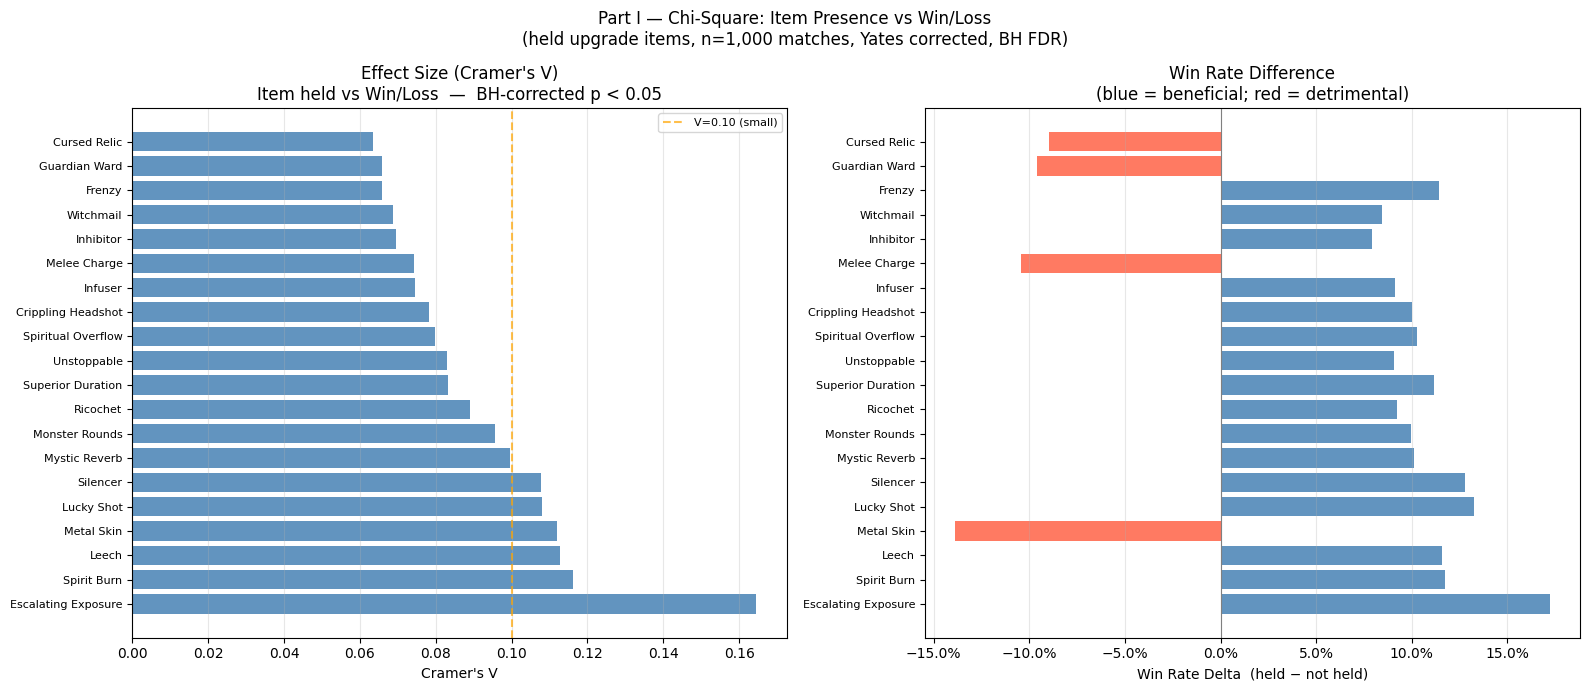

In [11]:
sig = chi_all_df[chi_all_df['p_bh'] < 0.05].head(20).copy()
sig['wr_delta'] = sig['wr_held'] - sig['wr_not_held']
y = np.arange(len(sig))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Cramer's V
ax = axes[0]
ax.barh(y, sig['cramers_v'], color='steelblue', alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(sig['item'], fontsize=8)
ax.set_xlabel("Cramer's V")
ax.set_title("Effect Size (Cramer's V)\nItem held vs Win/Loss  —  BH-corrected p < 0.05")
ax.axvline(0.1, color='orange', linestyle='--', alpha=0.7, label='V=0.10 (small)')
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.3)

# Right: Win-rate delta
ax = axes[1]
colors = ['steelblue' if d > 0 else 'tomato' for d in sig['wr_delta']]
ax.barh(y, sig['wr_delta'], color=colors, alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(sig['item'], fontsize=8)
ax.set_xlabel('Win Rate Delta  (held − not held)')
ax.set_title('Win Rate Difference\n(blue = beneficial; red = detrimental)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.axvline(0, color='grey', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

fig.suptitle('Part I — Chi-Square: Item Presence vs Win/Loss\n'
             f'(held upgrade items, n={len(raw_matches):,} matches, Yates corrected, BH FDR)',
             fontsize=12)
plt.tight_layout()
plt.show()


In [12]:
purchase_chi_rows = []
for item, (hero, _) in COUNTER_PAIRS.items():
    enemy_col  = f'enemy_has_{hero}'
    bought_col = f'bought_{item}'

    for tier in TIERS:
        grp = model_df[model_df['skill_tier'] == tier]
        if len(grp) < 20:
            continue
        ct = pd.crosstab(grp[bought_col], grp[enemy_col])
        ct = ct.reindex(index=[0, 1], columns=[0, 1], fill_value=0)
        n  = int(ct.values.sum())
        chi2, p, _, expected = chi2_contingency(ct.values, correction=True)
        v     = cramers_v(chi2, n)
        r_w   = ct.loc[1, 1] / ct[[1]].values.sum() if ct[[1]].values.sum() else np.nan
        r_wo  = ct.loc[1, 0] / ct[[0]].values.sum() if ct[[0]].values.sum() else np.nan
        purchase_chi_rows.append({
            'item':              item,
            'target_hero':       hero,
            'skill_tier':        tier,
            'n':                 n,
            'n_enemy_present':   int(ct[[1]].values.sum()),
            'buy_rate_w_enemy':  round(r_w,  3) if not np.isnan(r_w)  else np.nan,
            'buy_rate_wo_enemy': round(r_wo, 3) if not np.isnan(r_wo) else np.nan,
            'chi2':              round(chi2, 3),
            'p_value':           round(p, 4),
            'cramers_v':         round(v, 3),
            'min_expected':      round(expected.min(), 1),
        })

purchase_chi_df = pd.DataFrame(purchase_chi_rows)
display(purchase_chi_df.to_string(index=False))


'         item target_hero skill_tier   n  n_enemy_present  buy_rate_w_enemy  buy_rate_wo_enemy   chi2  p_value  cramers_v  min_expected\n    Knockdown      Dynamo        low 501               77             0.234              0.342  3.001   0.0832      0.077          25.1\n    Knockdown      Dynamo        mid 503              116             0.371              0.295  2.067   0.1505      0.064          36.2\n    Knockdown      Dynamo       high 513              120             0.367              0.303  1.448   0.2289      0.053          38.1\n    Knockdown      Dynamo        top 483              115             0.313              0.310  0.000   1.0000      0.000          35.7\nDisarming Hex        Haze        low 501              125             0.128              0.112  0.110   0.7399      0.015          14.5\nDisarming Hex        Haze        mid 503              143             0.182              0.131  1.774   0.1829      0.059          20.8\nDisarming Hex        Haze       high 513

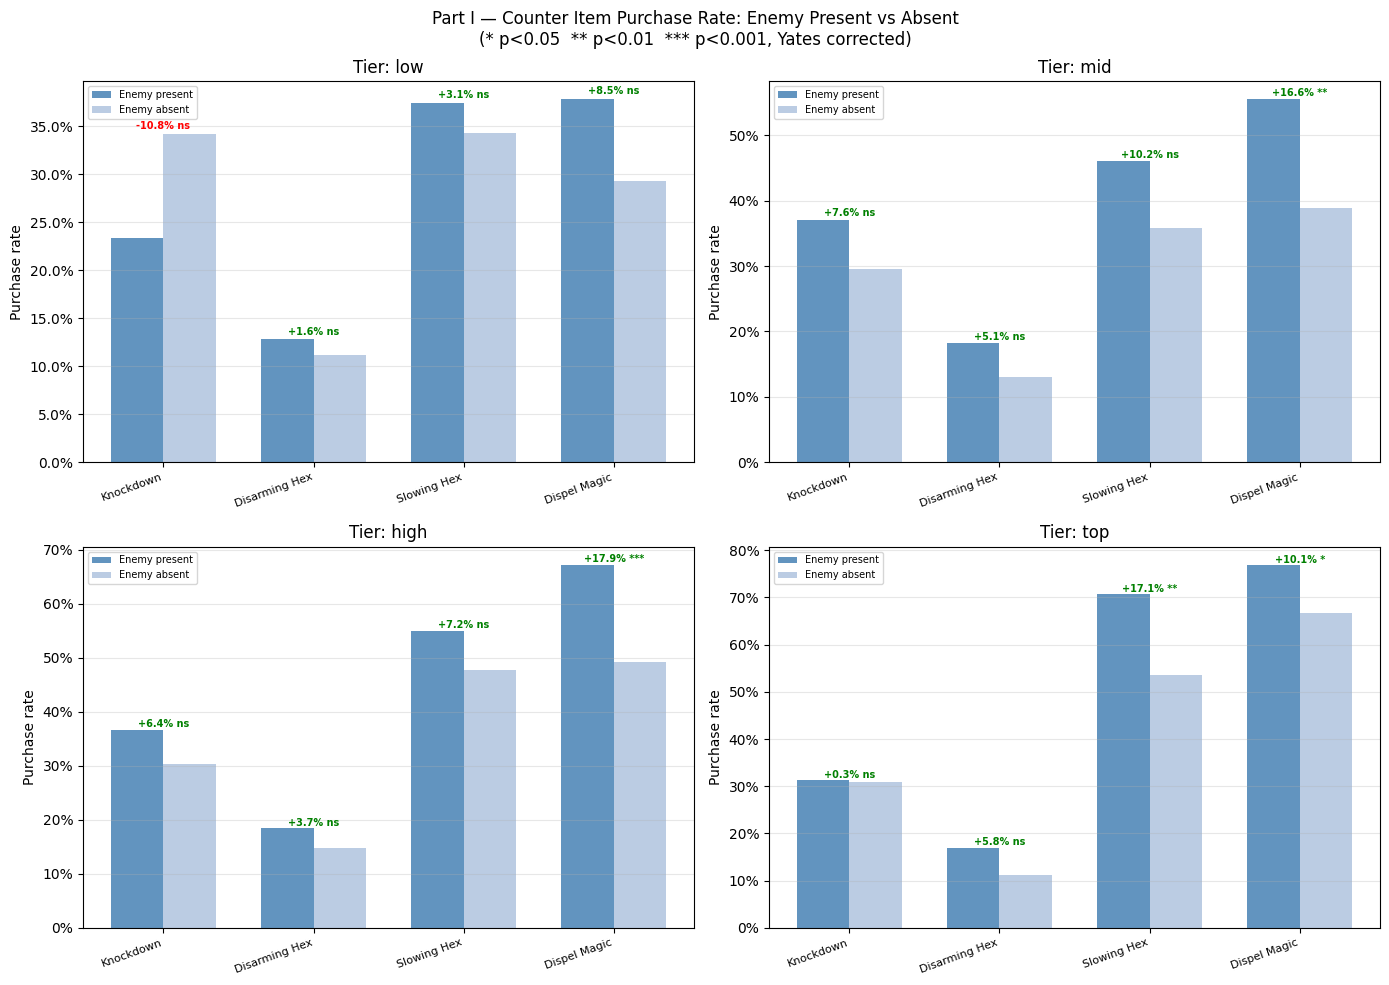

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
axes_flat = axes.flatten()
items_list = list(COUNTER_PAIRS.keys())
x, width   = np.arange(len(items_list)), 0.35

for ax, tier in zip(axes_flat, TIERS):
    sub = purchase_chi_df[purchase_chi_df['skill_tier'] == tier]
    if sub.empty:
        ax.set_title(f'Tier: {tier} — no data'); continue
    sub = sub.set_index('item').reindex(items_list)

    ax.bar(x - width/2, sub['buy_rate_w_enemy'],  width,
           label='Enemy present',  color='steelblue',      alpha=0.85)
    ax.bar(x + width/2, sub['buy_rate_wo_enemy'], width,
           label='Enemy absent',   color='lightsteelblue', alpha=0.85)

    for i, row in enumerate(sub.itertuples()):
        if pd.isna(row.buy_rate_w_enemy) or pd.isna(row.buy_rate_wo_enemy):
            continue
        delta = row.buy_rate_w_enemy - row.buy_rate_wo_enemy
        star  = ('***' if row.p_value < 0.001 else
                 '**'  if row.p_value < 0.01  else
                 '*'   if row.p_value < 0.05  else 'ns')
        color = 'green' if delta > 0 else 'red'
        ypos  = max(row.buy_rate_w_enemy, row.buy_rate_wo_enemy) + 0.005
        ax.annotate(f'{delta:+.1%} {star}', xy=(i, ypos),
                    ha='center', fontsize=7, color=color, fontweight='bold')

    ax.set_title(f'Tier: {tier}')
    ax.set_xticks(x)
    ax.set_xticklabels(items_list, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('Purchase rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Part I — Counter Item Purchase Rate: Enemy Present vs Absent\n'
             '(* p<0.05  ** p<0.01  *** p<0.001, Yates corrected)',
             fontsize=12)
plt.tight_layout()
plt.show()


## Part II — Logistic Regression

**Step 1 (Two-Proportion Z-Test):** Within matches where the target hero is on the enemy team, compare win rates between teams that held the counter item and those that did not. One-tailed test (H₁: buying counter item improves win rate). Run independently per skill tier.

**Step 2 (Logistic Regression — per pair):** Model win probability as a function of item held, enemy hero presence, and skill tier. Reports odds ratios with 95% confidence intervals, AUC/ROC, and Hosmer-Lemeshow goodness-of-fit.

**Step 3 (Broader character subset):** For each target hero context, identify all items with a significant win-rate association (from Part I) and fit a regularized model to rank their relative contributions.


In [14]:
ztest_rows = []
for item, (hero, _) in COUNTER_PAIRS.items():
    enemy_col = f'enemy_has_{hero}'
    held_col  = f'held_{item}'

    for tier in TIERS:
        grp    = model_df[model_df['skill_tier'] == tier]
        facing = grp[grp[enemy_col] == 1]
        n_total = len(facing)

        if n_total < 20:
            ztest_rows.append({'item': item, 'target_hero': hero, 'skill_tier': tier,
                                'n_with': 0, 'n_without': 0,
                                'wr_with': np.nan, 'wr_without': np.nan,
                                'wr_delta': np.nan, 'z_stat': np.nan,
                                'p_value': np.nan, 'note': f'n={n_total}<20'})
            continue

        with_item    = facing[facing[held_col] == 1]['won']
        without_item = facing[facing[held_col] == 0]['won']
        n1, n2 = len(with_item), len(without_item)

        if n1 < 5 or n2 < 5:
            ztest_rows.append({'item': item, 'target_hero': hero, 'skill_tier': tier,
                                'n_with': n1, 'n_without': n2,
                                'wr_with': with_item.mean() if n1 else np.nan,
                                'wr_without': without_item.mean() if n2 else np.nan,
                                'wr_delta': np.nan, 'z_stat': np.nan,
                                'p_value': np.nan, 'note': 'cell<5'})
            continue

        # One-tailed: H1: p_with > p_without
        z, p = proportions_ztest(
            count=np.array([with_item.sum(), without_item.sum()]),
            nobs=np.array([n1, n2]),
            alternative='larger',
        )
        star = ('***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')
        ztest_rows.append({
            'item':          item,
            'target_hero':   hero,
            'skill_tier':    tier,
            'n_with':        n1,
            'n_without':     n2,
            'wr_with':       round(float(with_item.mean()),    3),
            'wr_without':    round(float(without_item.mean()), 3),
            'wr_delta':      round(float(with_item.mean() - without_item.mean()), 3),
            'z_stat':        round(float(z), 3),
            'p_value':       round(float(p), 4),
            'note':          star,
        })

ztest_df = pd.DataFrame(ztest_rows)
display(ztest_df.to_string(index=False))


'         item target_hero skill_tier  n_with  n_without  wr_with  wr_without  wr_delta  z_stat  p_value note\n    Knockdown      Dynamo        low      16         61    0.312       0.525    -0.212  -1.511   0.9346     \n    Knockdown      Dynamo        mid      43         73    0.395       0.411    -0.016  -0.165   0.5657     \n    Knockdown      Dynamo       high      42         78    0.500       0.500     0.000   0.000   0.5000     \n    Knockdown      Dynamo        top      35         80    0.429       0.375     0.054   0.542   0.2940     \nDisarming Hex        Haze        low      14        111    0.571       0.441     0.130   0.920   0.1787     \nDisarming Hex        Haze        mid      23        120    0.391       0.450    -0.059  -0.519   0.6983     \nDisarming Hex        Haze       high      27        125    0.259       0.456    -0.197  -1.878   0.9698     \nDisarming Hex        Haze        top      23        112    0.478       0.491    -0.013  -0.112   0.5446     \n  Slowing

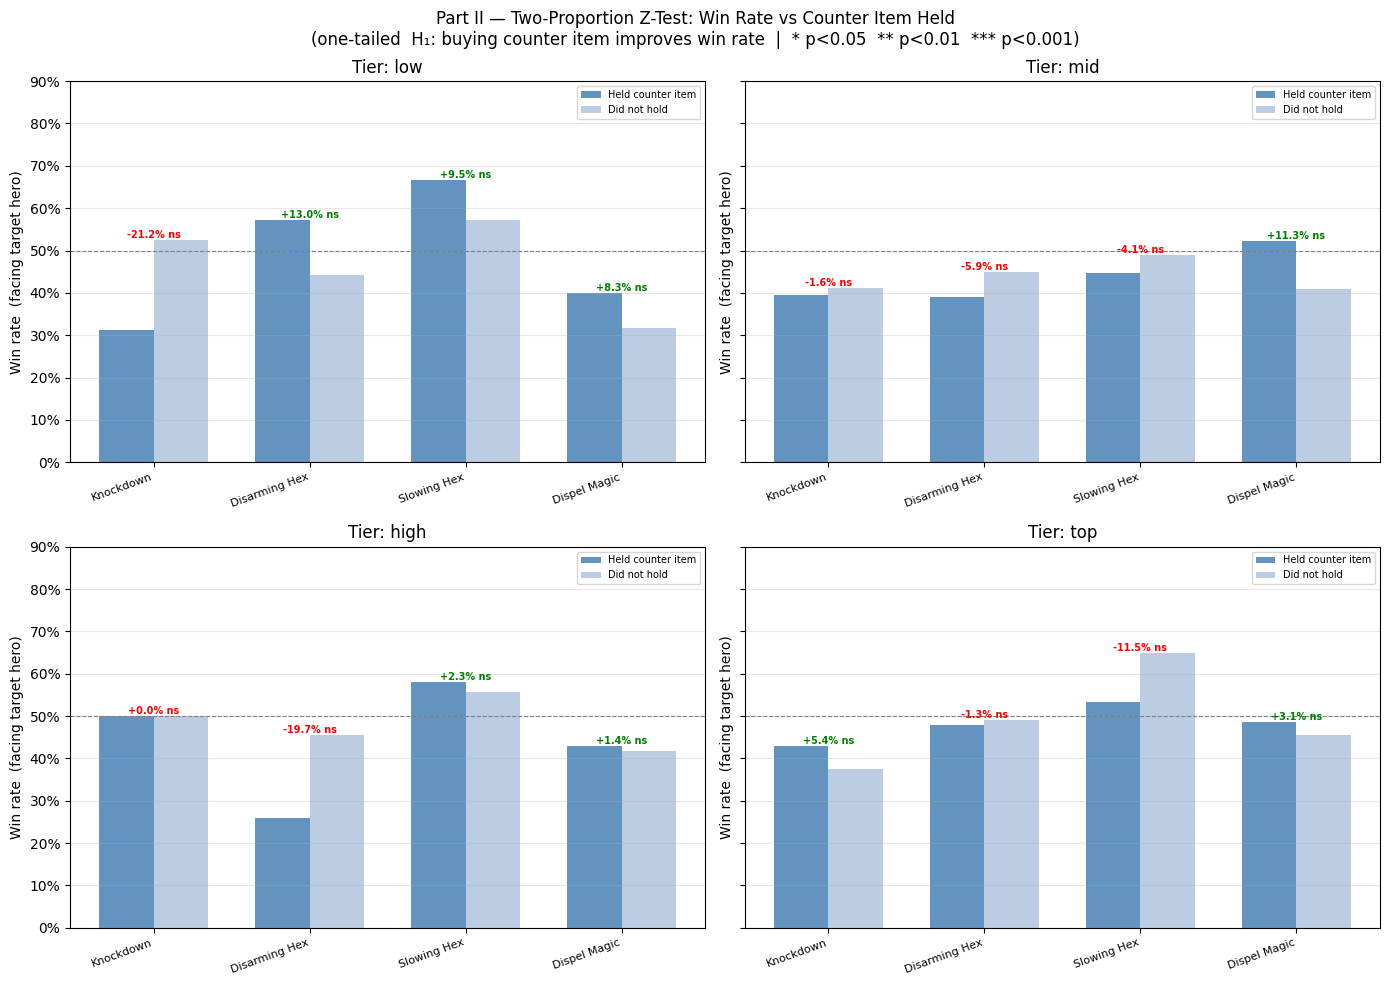

In [15]:
valid = ztest_df[ztest_df['wr_with'].notna()].copy()
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes_flat  = axes.flatten()
x, width   = np.arange(len(items_list)), 0.35

for ax, tier in zip(axes_flat, TIERS):
    sub = valid[valid['skill_tier'] == tier].set_index('item').reindex(items_list)
    ax.bar(x - width/2, sub['wr_with'],    width, label='Held counter item', color='steelblue',      alpha=0.85)
    ax.bar(x + width/2, sub['wr_without'], width, label='Did not hold',      color='lightsteelblue', alpha=0.85)
    ax.axhline(0.5, color='grey', linewidth=0.8, linestyle='--')

    for i, row in enumerate(sub.itertuples()):
        if pd.isna(row.wr_delta): continue
        star  = row.note if row.note else 'ns'
        color = 'green' if row.wr_delta > 0 else 'red'
        ypos  = max(row.wr_with, row.wr_without) + 0.005
        ax.annotate(f'{row.wr_delta:+.1%} {star}', xy=(i, ypos),
                    ha='center', fontsize=7, color=color, fontweight='bold')

    ax.set_title(f'Tier: {tier}')
    ax.set_xticks(x)
    ax.set_xticklabels(items_list, rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('Win rate  (facing target hero)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylim(0, 0.90)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Part II — Two-Proportion Z-Test: Win Rate vs Counter Item Held\n'
             '(one-tailed  H₁: buying counter item improves win rate  |  * p<0.05  ** p<0.01  *** p<0.001)',
             fontsize=12)
plt.tight_layout()
plt.show()


In [16]:
def hosmer_lemeshow(y_true, y_pred, n_groups=10):
    """Hosmer-Lemeshow goodness-of-fit chi-square and p-value."""
    df = pd.DataFrame({'y': np.asarray(y_true), 'p': np.asarray(y_pred)})
    df['grp'] = pd.qcut(df['p'], q=n_groups, duplicates='drop', labels=False)
    rows = []
    for _, grp in df.groupby('grp'):
        rows.append({'op': grp['y'].sum(), 'ep': grp['p'].sum(),
                     'on': len(grp) - grp['y'].sum(),
                     'en': len(grp) - grp['p'].sum()})
    hl = pd.DataFrame(rows)
    stat = (
        ((hl['op'] - hl['ep'])**2 / hl['ep'].clip(1e-10)).sum() +
        ((hl['on'] - hl['en'])**2 / hl['en'].clip(1e-10)).sum()
    )
    dof = len(hl) - 2
    return float(stat), float(stats.chi2.sf(stat, dof)), dof


lr_rows = []
for item, (hero, _) in COUNTER_PAIRS.items():
    enemy_col = f'enemy_has_{hero}'
    held_col  = f'held_{item}'

    sub = model_df[[held_col, enemy_col, 'skill_tier', 'won']].dropna()
    tier_d = pd.get_dummies(sub['skill_tier'], prefix='tier', drop_first=True)
    X = sm.add_constant(
        pd.concat([sub[[held_col, enemy_col]].reset_index(drop=True),
                   tier_d.astype(int).reset_index(drop=True)], axis=1).astype(float)
    )
    y = sub['won'].reset_index(drop=True)

    try:
        result   = sm.Logit(y, X).fit(disp=False, maxiter=300)
        ci       = result.conf_int()
        coef     = float(result.params[held_col])
        ci_lo, ci_hi = float(ci.loc[held_col, 0]), float(ci.loc[held_col, 1])
        p_val    = float(result.pvalues[held_col])
        y_pred   = result.predict(X)
        auc      = roc_auc_score(y, y_pred)
        hl_stat, hl_p, hl_dof = hosmer_lemeshow(y, y_pred)
        lr_rows.append({
            'item':        item,
            'target_hero': hero,
            'coef':        round(coef, 3),
            'odds_ratio':  round(np.exp(coef), 3),
            'ci_low':      round(np.exp(ci_lo), 3),
            'ci_high':     round(np.exp(ci_hi), 3),
            'p_value':     round(p_val, 4),
            'pseudo_r2':   round(float(result.prsquared), 4),
            'auc':         round(auc, 3),
            'hl_stat':     round(hl_stat, 2),
            'hl_p':        round(hl_p, 4),
            'converged':   result.mle_retvals['converged'],
        })
    except Exception as e:
        print(f'{item}: {e}')

lr_df = pd.DataFrame(lr_rows)
display(lr_df.to_string(index=False))


'         item target_hero   coef  odds_ratio  ci_low  ci_high  p_value  pseudo_r2   auc  hl_stat   hl_p  converged\n    Knockdown      Dynamo -0.124       0.884   0.730    1.069   0.2036     0.0034 0.538     2.79 0.8347       True\nDisarming Hex        Haze -0.314       0.731   0.561    0.952   0.0200     0.0048 0.539     1.19 0.9456       True\n  Slowing Hex        Mina -0.104       0.901   0.741    1.096   0.2960     0.0030 0.531     3.22 0.8644       True\n Dispel Magic    Infernus  0.095       1.100   0.914    1.323   0.3147     0.0045 0.538     3.14 0.7914       True'

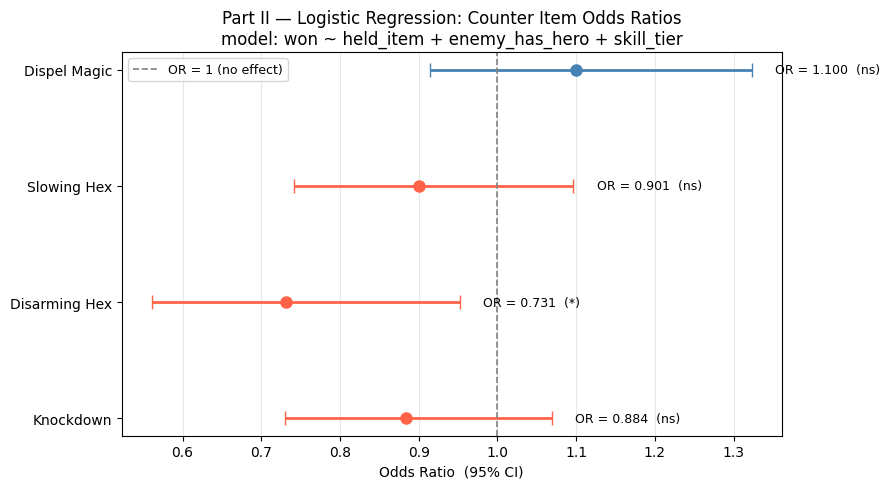

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(lr_df))

for i, row in lr_df.iterrows():
    color = 'steelblue' if row['odds_ratio'] > 1 else 'tomato'
    ax.errorbar(
        x    = row['odds_ratio'],
        y    = i,
        xerr = [[row['odds_ratio'] - row['ci_low']],
                [row['ci_high']   - row['odds_ratio']]],
        fmt='o', color=color, capsize=5, markersize=8, linewidth=2,
    )
    star = ('***' if row['p_value'] < 0.001 else
            '**'  if row['p_value'] < 0.01  else
            '*'   if row['p_value'] < 0.05  else 'ns')
    ax.text(row['ci_high'] + 0.03, i,
            f"OR = {row['odds_ratio']:.3f}  ({star})",
            va='center', fontsize=9)

ax.axvline(1.0, color='grey', linestyle='--', linewidth=1.2, label='OR = 1 (no effect)')
ax.set_yticks(y_pos)
ax.set_yticklabels(lr_df['item'], fontsize=10)
ax.set_xlabel('Odds Ratio  (95% CI)')
ax.set_title('Part II — Logistic Regression: Counter Item Odds Ratios\n'
             'model: won ~ held_item + enemy_has_hero + skill_tier')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


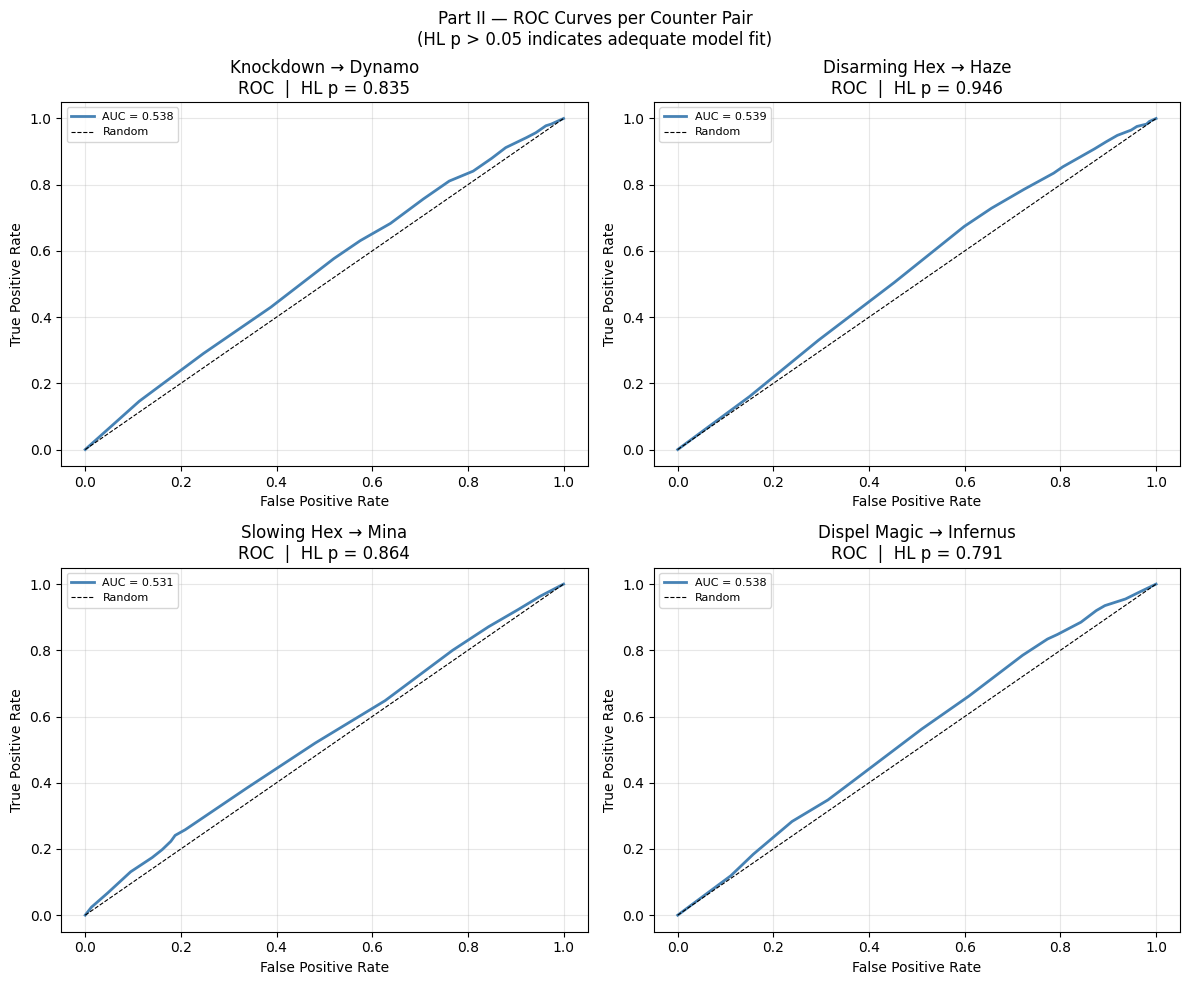

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes_flat = axes.flatten()

for ax, (item, (hero, _)) in zip(axes_flat, COUNTER_PAIRS.items()):
    held_col  = f'held_{item}'
    enemy_col = f'enemy_has_{hero}'
    sub = model_df[[held_col, enemy_col, 'skill_tier', 'won']].dropna()
    tier_d = pd.get_dummies(sub['skill_tier'], prefix='tier', drop_first=True)
    X = sm.add_constant(
        pd.concat([sub[[held_col, enemy_col]].reset_index(drop=True),
                   tier_d.astype(int).reset_index(drop=True)], axis=1).astype(float)
    )
    y = sub['won'].reset_index(drop=True)
    result = sm.Logit(y, X).fit(disp=False, maxiter=300)
    y_pred = result.predict(X)
    fpr, tpr, _ = roc_curve(y, y_pred)
    auc = roc_auc_score(y, y_pred)
    hl_stat, hl_p, _ = hosmer_lemeshow(y, y_pred)

    ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{item} → {hero}\nROC  |  HL p = {hl_p:.3f}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Part II — ROC Curves per Counter Pair\n'
             '(HL p > 0.05 indicates adequate model fit)', fontsize=12)
plt.tight_layout()
plt.show()


In [19]:
combined_feats = (
    [f'held_{i}'       for i in COUNTER_PAIRS] +
    [f'enemy_has_{h}'  for h, _ in COUNTER_PAIRS.values()]
)
sub = model_df[combined_feats + ['skill_tier', 'won']].dropna()
tier_d = pd.get_dummies(sub['skill_tier'], prefix='tier', drop_first=True)
X_vif = sm.add_constant(
    pd.concat([sub[combined_feats].reset_index(drop=True),
               tier_d.astype(int).reset_index(drop=True)], axis=1).astype(float)
)

vif_df = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF':     [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
print('Variance Inflation Factors  (VIF > 10 indicates multicollinearity):')
display(vif_df[vif_df['feature'] != 'const'].sort_values('VIF', ascending=False).round(2))


Variance Inflation Factors  (VIF > 10 indicates multicollinearity):


,feature,VIF
11,tier_top,1.67
10,tier_high,1.57
9,tier_mid,1.52
4,held_Dispel Magic,1.11
3,held_Slowing Hex,1.05
8,enemy_has_Infernus,1.03
6,enemy_has_Haze,1.03
7,enemy_has_Mina,1.03
2,held_Disarming Hex,1.02
5,enemy_has_Dynamo,1.01


In [20]:
# For each target hero, fit a logistic regression using items that are:
#   (a) significant in the overall chi-square (Part I, BH < 0.05)
#   (b) held by ≥ 5% of teams in matches where this hero is on the enemy team
# This shows which items matter most in each hero's specific context.

sig_items_set = set(chi_all_df[chi_all_df['p_bh'] < 0.05]['item'])

broad_rows = []
for item, (hero, _) in COUNTER_PAIRS.items():
    enemy_col = f'enemy_has_{hero}'
    facing    = model_df[model_df[enemy_col] == 1][['match_id', 'team', 'skill_tier', 'won']]

    if len(facing) < 30:
        print(f'{hero}: only {len(facing)} facing rows — skipping broad model')
        continue

    ip_cols = ['match_id', 'team'] + [c for c in item_presence.columns
                                       if c not in ('match_id', 'team', 'won')]
    ip_facing = (
        item_presence[ip_cols][item_presence['match_id'].isin(facing['match_id'])]
        .merge(facing[['match_id', 'team', 'skill_tier', 'won']], on=['match_id', 'team'])
    )
    avail = [c for c in sig_items_set if c in ip_facing.columns]
    hold_rates = ip_facing[avail].mean()
    selected   = hold_rates[hold_rates >= 0.05].index.tolist()

    if len(selected) < 2:
        print(f'{hero}: fewer than 2 eligible items — skipping')
        continue

    tier_d = pd.get_dummies(ip_facing['skill_tier'], prefix='tier', drop_first=True)
    X = sm.add_constant(
        pd.concat([ip_facing[selected].reset_index(drop=True),
                   tier_d.astype(int).reset_index(drop=True)], axis=1).astype(float)
    )
    y = ip_facing['won'].reset_index(drop=True)

    try:
        result = sm.Logit(y, X).fit(disp=False, maxiter=400)
        ci     = result.conf_int()
        for feat in selected:
            if feat not in result.params.index:
                continue
            broad_rows.append({
                'target_hero': hero,
                'item':        feat,
                'odds_ratio':  round(np.exp(float(result.params[feat])), 3),
                'ci_low':      round(np.exp(float(ci.loc[feat, 0])),    3),
                'ci_high':     round(np.exp(float(ci.loc[feat, 1])),    3),
                'p_value':     round(float(result.pvalues[feat]),        4),
            })
    except Exception as e:
        print(f'{hero}: {e}')

broad_df = pd.DataFrame(broad_rows)
sig_broad = broad_df[broad_df['p_value'] < 0.05].sort_values(['target_hero', 'p_value'])
print(f'Significant predictors across all hero contexts (p < 0.05):')
display(sig_broad.to_string(index=False))


Significant predictors across all hero contexts (p < 0.05):


"target_hero                item  odds_ratio  ci_low  ci_high  p_value\n     Dynamo          Metal Skin       0.456   0.270    0.769   0.0032\n     Dynamo      Monster Rounds       1.874   1.158    3.030   0.0105\n     Dynamo      Divine Barrier       1.988   1.157    3.415   0.0128\n     Dynamo       Hunter's Aura       1.785   1.120    2.845   0.0148\n     Dynamo         Spirit Burn       1.780   1.116    2.841   0.0155\n       Haze          Metal Skin       0.410   0.276    0.609   0.0000\n       Haze      Monster Rounds       1.838   1.228    2.751   0.0031\n       Haze Escalating Exposure       1.889   1.236    2.889   0.0033\n       Haze       Mystic Reverb       1.575   1.065    2.329   0.0228\n       Haze       Hunter's Aura       1.578   1.059    2.352   0.0250\n   Infernus          Metal Skin       0.483   0.282    0.828   0.0082\n   Infernus      Monster Rounds       1.792   1.155    2.780   0.0092\n   Infernus        Cursed Relic       0.463   0.255    0.843   0.0117\n   In

## Part III — Volcano Plot: Item × Hero Interaction Patterns

For every (item, hero) combination with adequate sample size:
- **x-axis:** log₂(Odds Ratio) — positive = item associated with higher win rate when facing that hero
- **y-axis:** −log₁₀(adjusted p-value) — higher = more significant

Multiple testing correction applied using Benjamini-Hochberg FDR (and Bonferroni as a robustness check). Points above the p-threshold line and beyond the OR threshold are annotated.

This surface simultaneously answers which items are context-specific counters vs universally advantageous, and which are detrimental regardless of hero.


In [21]:
# Enemy hero flags for ALL heroes (shifted to the opposing team's perspective)
enemy_hero_presence = hero_presence[['match_id', 'team'] + hero_cols_all].copy()
enemy_hero_presence['team'] = enemy_hero_presence['team'].map(OTHER_TEAM)
enemy_hero_cols = [f'enemy_{h}' for h in hero_cols_all]
enemy_hero_presence.columns = ['match_id', 'team'] + enemy_hero_cols

volcano_frame = (
    item_presence[['match_id', 'team', 'won'] + item_cols]
    .merge(enemy_hero_presence, on=['match_id', 'team'], how='left')
    .fillna(0)
)
print('volcano_frame shape:', volcano_frame.shape)


volcano_frame shape: (2000, 195)


In [22]:
MIN_N_WITH  = 15   # min teams holding item when facing hero
MIN_FACING  = 50   # min teams facing hero

volcano_rows = []
for hero, ecol in zip(hero_cols_all, enemy_hero_cols):
    facing = volcano_frame[volcano_frame[ecol] == 1]
    if len(facing) < MIN_FACING:
        continue

    for item in item_cols:
        with_item    = facing[facing[item] == 1]['won']
        without_item = facing[facing[item] == 0]['won']
        n1, n0 = len(with_item), len(without_item)
        if n1 < MIN_N_WITH or n0 < 5:
            continue

        a = int(with_item.sum())
        b = n1 - a
        c = int(without_item.sum())
        d = n0 - c
        if b == 0 or c == 0:     # undefined OR
            continue

        chi2, p, _, _ = chi2_contingency(
            np.array([[a, b], [c, d]]), correction=False
        )
        or_val = (a * d) / (b * c)
        volcano_rows.append({
            'item':     item,
            'hero':     hero,
            'n_with':   n1,
            'n_without':n0,
            'wr_with':  round(float(with_item.mean()),    3),
            'wr_without':round(float(without_item.mean()),3),
            'or':       or_val,
            'log2_or':  np.log2(or_val),
            'chi2':     chi2,
            'p_raw':    p,
        })

volcano_df = pd.DataFrame(volcano_rows)
print(f'(item, hero) pairs tested: {len(volcano_df):,}')
display(volcano_df[['or', 'log2_or', 'p_raw']].describe().round(3))


(item, hero) pairs tested: 5,448


,or,log2_or,p_raw
count,5448.000,5448.000,5448.000
mean,1.159,0.113,0.438
std,0.495,0.529,0.303
min,0.216,-2.209,0.000
25%,0.855,-0.225,0.157
50%,1.079,0.110,0.411
75%,1.359,0.443,0.700
max,16.632,4.056,1.000


In [23]:
_, volcano_df['p_bh'],   _, _ = multipletests(volcano_df['p_raw'], method='fdr_bh')
_, volcano_df['p_bonf'], _, _ = multipletests(volcano_df['p_raw'], method='bonferroni')
volcano_df['neg_log10_bh'] = -np.log10(volcano_df['p_bh'].clip(lower=1e-300))

THRESH_P  = 0.05
THRESH_OR = np.log2(1.2)   # OR ≥ 1.2 or ≤ 1/1.2

def categorise(row):
    if row['p_bh'] >= THRESH_P:
        return 'non-significant'
    if row['log2_or'] >  THRESH_OR:
        return 'beneficial'
    if row['log2_or'] < -THRESH_OR:
        return 'detrimental'
    return 'significant-small-effect'

volcano_df['category'] = volcano_df.apply(categorise, axis=1)
print('Category counts:')
print(volcano_df['category'].value_counts().to_string())


Category counts:
category
non-significant    5422
beneficial           23
detrimental           3


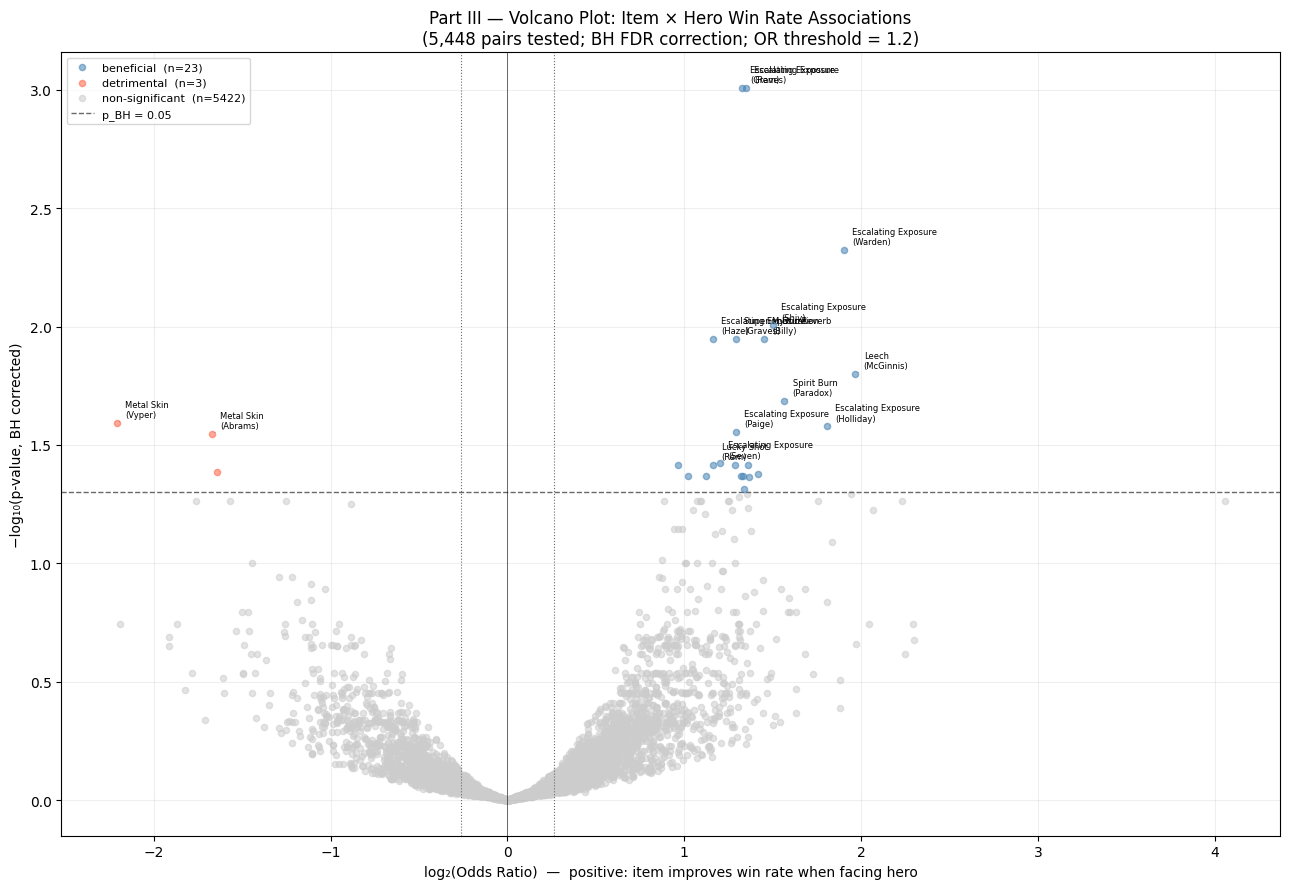

In [24]:
palette = {
    'beneficial':              'steelblue',
    'detrimental':             'tomato',
    'significant-small-effect':'orange',
    'non-significant':         '#cccccc',
}
z_order = {'non-significant': 1, 'significant-small-effect': 2,
            'detrimental': 3, 'beneficial': 4}

fig, ax = plt.subplots(figsize=(13, 9))

for cat, grp in volcano_df.groupby('category'):
    ax.scatter(grp['log2_or'], grp['neg_log10_bh'],
               c=palette[cat], alpha=0.55, s=20,
               label=f'{cat}  (n={len(grp)})',
               zorder=z_order.get(cat, 2))

ax.axhline(-np.log10(THRESH_P), color='dimgrey', linestyle='--',
           linewidth=1, label=f'p_BH = {THRESH_P}')
ax.axvline( THRESH_OR, color='dimgrey', linestyle=':', linewidth=0.8)
ax.axvline(-THRESH_OR, color='dimgrey', linestyle=':', linewidth=0.8)
ax.axvline(0,          color='black',   linewidth=0.4)

# Annotate top hits by significance
top_hits = (
    volcano_df[volcano_df['category'].isin(['beneficial', 'detrimental'])]
    .nlargest(15, 'neg_log10_bh')
)
for _, row in top_hits.iterrows():
    ax.annotate(
        f"{row['item']}\n({row['hero']})",
        xy=(row['log2_or'], row['neg_log10_bh']),
        xytext=(6, 4), textcoords='offset points',
        fontsize=6, color='black',
        arrowprops=dict(arrowstyle='-', color='grey', lw=0.5),
    )

ax.set_xlabel('log₂(Odds Ratio)  —  positive: item improves win rate when facing hero', fontsize=10)
ax.set_ylabel('−log₁₀(p-value, BH corrected)', fontsize=10)
ax.set_title(
    f'Part III — Volcano Plot: Item × Hero Win Rate Associations\n'
    f'({len(volcano_df):,} pairs tested; BH FDR correction; OR threshold = 1.2)',
    fontsize=12,
)
ax.legend(loc='upper left', fontsize=8, framealpha=0.8)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


Items beneficial when facing ≥ 2 different heroes (systemic advantage):


,n_heroes_beneficial
item,
Escalating Exposure,12
Mystic Reverb,3
Leech,2
Spirit Burn,2


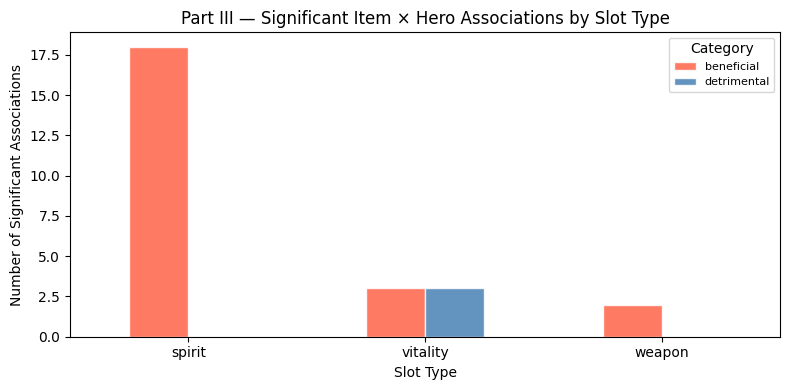

In [25]:
# How many heroes is each item beneficial against?
sig_per_item = (
    volcano_df[volcano_df['category'] == 'beneficial']
    .groupby('item')['hero']
    .count()
    .rename('n_heroes_beneficial')
    .sort_values(ascending=False)
)
print('Items beneficial when facing ≥ 2 different heroes (systemic advantage):')
display(sig_per_item[sig_per_item >= 2].to_frame())

# Slot-type breakdown of significant associations
item_slot = (
    items_lookup[items_lookup['type'] == 'upgrade']
    [['name', 'slot_type']]
    .set_index('name')
)
sig_volcano = volcano_df[volcano_df['category'].isin(['beneficial', 'detrimental'])].copy()
sig_volcano = sig_volcano.join(item_slot, on='item', how='left')

slot_counts = (
    sig_volcano
    .groupby(['slot_type', 'category'])
    .size()
    .unstack(fill_value=0)
)
slot_counts.plot(kind='bar', figsize=(8, 4),
                 color=['tomato', 'steelblue', 'orange'][:len(slot_counts.columns)],
                 alpha=0.85, edgecolor='white')
plt.title('Part III — Significant Item × Hero Associations by Slot Type')
plt.xlabel('Slot Type')
plt.ylabel('Number of Significant Associations')
plt.xticks(rotation=0)
plt.legend(title='Category', fontsize=8)
plt.tight_layout()
plt.show()


## Secondary Analysis — Time Series: Purchase Rate vs Hero Win Rate

For each counter pair, track weekly item purchase rate and target hero win rate over the sample window. A Pearson correlation tests whether the community adjusts buying behavior in response to hero performance.

**Note:** The sample (`collected_matches_sample.jsonl`) spans approximately one day, so this analysis will flag insufficient temporal coverage and recommend running on the full dataset. The cell produces plots if ≥ 3 distinct weeks are present.


In [26]:
model_df['week'] = model_df['start_time'].dt.to_period('W')

ts_purchase = (
    model_df
    .groupby('week')[[f'bought_{i}' for i in COUNTER_PAIRS]]
    .mean()
    .rename(columns={f'bought_{i}': i for i in COUNTER_PAIRS})
)

target_hero_names = [h for h, _ in COUNTER_PAIRS.values()]
hero_wr_weekly = (
    players_df[players_df['hero_name'].isin(target_hero_names)]
    .assign(week=players_df['start_time'].dt.to_period('W'))
    .groupby(['week', 'hero_name'])['won']
    .mean()
    .unstack('hero_name')
)

common_weeks = ts_purchase.index.intersection(hero_wr_weekly.index)
print(f'Distinct weeks in sample: {len(common_weeks)}')

if len(common_weeks) < 3:
    print('\nInsufficient temporal coverage for rolling analysis.')
    print('Re-run on data/collected_matches.jsonl + collected_matches_gap.jsonl '
          'to obtain the full 34-week time series.')
else:
    ts_p = ts_purchase.reindex(common_weeks)
    ts_h = hero_wr_weekly.reindex(common_weeks)

    fig, axes = plt.subplots(len(COUNTER_PAIRS), 1,
                              figsize=(12, 3.5 * len(COUNTER_PAIRS)), sharex=True)
    for ax, (item, (hero, _)) in zip(axes, COUNTER_PAIRS.items()):
        ax2 = ax.twinx()
        xs  = range(len(common_weeks))
        ax.plot(xs,  ts_p[item].values,   'o-', color='steelblue', label=f'{item} purchase rate')
        ax2.plot(xs, ts_h[hero].values,   's--', color='tomato',   label=f'{hero} win rate')
        ax.set_ylabel('Purchase rate', color='steelblue')
        ax2.set_ylabel('Win rate',     color='tomato')
        ax.set_title(f'{item}  ↔  {hero}')
        ax.legend(loc='upper left',  fontsize=8)
        ax2.legend(loc='upper right', fontsize=8)
        ax.grid(alpha=0.3)
    axes[-1].set_xticks(range(len(common_weeks)))
    axes[-1].set_xticklabels([str(w) for w in common_weeks], rotation=30, ha='right', fontsize=7)
    fig.suptitle('Secondary — Weekly Purchase Rate vs Hero Win Rate', fontsize=12)
    plt.tight_layout()
    plt.show()


Distinct weeks in sample: 1

Insufficient temporal coverage for rolling analysis.
Re-run on data/collected_matches.jsonl + collected_matches_gap.jsonl to obtain the full 34-week time series.


In [27]:
if len(common_weeks) >= 3:
    ts_p = ts_purchase.reindex(common_weeks)
    ts_h = hero_wr_weekly.reindex(common_weeks)

    corr_rows = []
    for item, (hero, _) in COUNTER_PAIRS.items():
        x = ts_p[item].dropna()
        y = ts_h[hero].dropna() if hero in ts_h.columns else pd.Series([], dtype=float)
        idx = x.index.intersection(y.index)
        if len(idx) < 3:
            continue
        r_p, p_p = pearsonr(x[idx].values,  y[idx].values)
        r_s, p_s = spearmanr(x[idx].values, y[idx].values)
        corr_rows.append({
            'item': item, 'target_hero': hero, 'n_weeks': len(idx),
            'pearson_r':  round(r_p, 3), 'pearson_p':  round(p_p, 4),
            'spearman_r': round(r_s, 3), 'spearman_p': round(p_s, 4),
        })
    if corr_rows:
        print('Pearson / Spearman correlations — purchase rate vs hero win rate:')
        display(pd.DataFrame(corr_rows).to_string(index=False))
    else:
        print('Insufficient paired weeks for correlation.')
else:
    print('Skipped — fewer than 3 common weeks in sample.')


Skipped — fewer than 3 common weeks in sample.


## Classification Summary

Each counter pair is classified using the criteria from the proposal:

| Label | Criteria |
|---|---|
| **Confirmed** | Significant elevation in *both* purchase rate AND conditional win rate |
| **Overrated** | Elevated purchase rate but no significant win rate lift |
| **Undiscovered** | Significant win rate lift but purchase rate not meaningfully elevated |
| **Null** | Neither condition met |

Significance is based on the chi-square (purchase rate, Part I) and Z-test (win rate, Part II) results. A pair is considered significant in a criterion if *at least one skill tier* crosses p < 0.05.


In [28]:
class_rows = []
for item, (hero, _) in COUNTER_PAIRS.items():
    enemy_col = f'enemy_has_{hero}'
    held_col  = f'held_{item}'

    purch_sig_tiers = purchase_chi_df[
        (purchase_chi_df['item'] == item) & (purchase_chi_df['p_value'] < 0.05)
    ]['skill_tier'].tolist()

    wr_sig_tiers = ztest_df[
        (ztest_df['item'] == item) & (ztest_df['p_value'].fillna(1) < 0.05)
    ]['skill_tier'].tolist()

    purchase_elevated = len(purch_sig_tiers) > 0
    winrate_elevated  = len(wr_sig_tiers)   > 0

    if   purchase_elevated and winrate_elevated:   label = 'Confirmed'
    elif purchase_elevated and not winrate_elevated: label = 'Overrated'
    elif not purchase_elevated and winrate_elevated: label = 'Undiscovered'
    else:                                            label = 'Null'

    facing     = model_df[model_df[enemy_col] == 1]
    wr_with    = facing[facing[held_col] == 1]['won'].mean()
    wr_without = facing[facing[held_col] == 0]['won'].mean()

    # Cramer's V for purchase behavior (all tiers pooled)
    ct = pd.crosstab(
        model_df[f'bought_{item}'], model_df[enemy_col]
    ).reindex(index=[0,1], columns=[0,1], fill_value=0)
    chi2_p, _, _, _ = chi2_contingency(ct.values, correction=True)
    v_purchase = cramers_v(chi2_p, int(ct.values.sum()))

    # OR from per-pair logistic regression
    lr_row = lr_df[lr_df['item'] == item].iloc[0] if item in lr_df['item'].values else {}

    class_rows.append({
        'item':              item,
        'target_hero':       hero,
        'purch_sig_tiers':   ', '.join(purch_sig_tiers) or '—',
        'wr_sig_tiers':      ', '.join(wr_sig_tiers)    or '—',
        'cramers_v_purchase':round(v_purchase, 3),
        'lr_odds_ratio':     lr_row.get('odds_ratio', np.nan),
        'overall_wr_with':   round(float(wr_with),            3) if not pd.isna(wr_with)    else np.nan,
        'overall_wr_without':round(float(wr_without),         3) if not pd.isna(wr_without) else np.nan,
        'overall_wr_delta':  round(float(wr_with - wr_without),3) if not (pd.isna(wr_with) or pd.isna(wr_without)) else np.nan,
        'classification':    label,
    })

class_df = pd.DataFrame(class_rows)
display(class_df.to_string(index=False))


'         item target_hero purch_sig_tiers wr_sig_tiers  cramers_v_purchase  lr_odds_ratio  overall_wr_with  overall_wr_without  overall_wr_delta classification\n    Knockdown      Dynamo               —            —               0.013          0.884            0.426               0.449            -0.022           Null\nDisarming Hex        Haze               —            —               0.053          0.731            0.402               0.459            -0.057           Null\n  Slowing Hex        Mina             top            —               0.058          0.901            0.549               0.554            -0.005      Overrated\n Dispel Magic    Infernus  mid, high, top            —               0.133          1.100            0.467               0.390             0.077      Overrated'

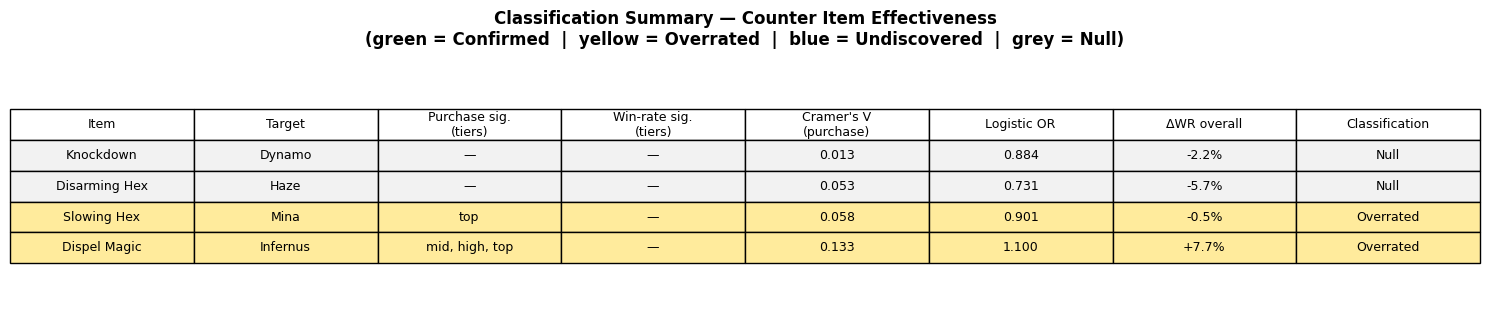

In [29]:
color_map = {
    'Confirmed':    '#c6efce',
    'Overrated':    '#ffeb9c',
    'Undiscovered': '#9dc3e6',
    'Null':         '#f2f2f2',
}

col_labels = [
    'Item', 'Target', 'Purchase sig.\n(tiers)', 'Win-rate sig.\n(tiers)',
    "Cramer's V\n(purchase)", 'Logistic OR', 'ΔWR overall', 'Classification',
]
table_data = [
    [
        r['item'], r['target_hero'],
        r['purch_sig_tiers'], r['wr_sig_tiers'],
        f"{r['cramers_v_purchase']:.3f}",
        f"{r['lr_odds_ratio']:.3f}" if not pd.isna(r['lr_odds_ratio']) else '—',
        f"{r['overall_wr_delta']:+.1%}" if not pd.isna(r['overall_wr_delta']) else '—',
        r['classification'],
    ]
    for _, r in class_df.iterrows()
]
row_colors = [
    [color_map.get(r['classification'], '#f2f2f2')] * len(col_labels)
    for _, r in class_df.iterrows()
]

fig, ax = plt.subplots(figsize=(15, 3.2))
ax.axis('off')
tbl = ax.table(
    cellText=table_data, colLabels=col_labels,
    cellLoc='center', loc='center', cellColours=row_colors,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 2.0)
ax.set_title('Classification Summary — Counter Item Effectiveness\n'
             '(green = Confirmed  |  yellow = Overrated  |  blue = Undiscovered  |  grey = Null)',
             fontsize=12, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()


## Conclusions

The classification table above answers the four research questions:

1. **Are counter items bought more when the target hero is present?**
   See the *Purchase sig. (tiers)* column and the Part I chi-square results. Items marked with any significant tier confirm counter-buying behavior exists in the data.

2. **Does buying the counter item improve win rate against that hero?**
   See the *Win-rate sig. (tiers)* column and the Part II Z-test/logistic regression results. The Logistic OR column gives the effect estimate controlling for skill tier and hero presence.

3. **Confirm, refute, or complicate community consensus?**
   Items classified as **Confirmed** validate the community belief. **Overrated** items are bought as intended but don't deliver a win-rate benefit. **Undiscovered** items outperform despite not being widely recognised as counters.

4. **Does effectiveness differ by skill tier?**
   Compare the per-tier bars in the Z-test visualization (Part II). Items whose significance is tier-restricted suggest skill-dependent effectiveness.

---

*Data source: `collected_matches_sample.jsonl` (1,000 matches).*
*Re-run on `collected_matches.jsonl` + `collected_matches_gap.jsonl` (~34 weeks) for production results.*
